In [1]:
# Core libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load MNIST — already split into train/test
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training samples:", X_train.shape)   # (60000, 28, 28)
print("Test samples    :", X_test.shape)    # (10000, 28, 28)
print("Pixel range before normalization:", X_train.min(), "to", X_train.max())

# --- Preprocessing Step 1: Reshape ---
# CNNs expect (samples, height, width, channels)
# MNIST is grayscale so channels = 1
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# --- Preprocessing Step 2: Normalize ---
# Scale pixel values from [0-255] to [0-1]
# This helps the model train faster and more stably
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

print("Pixel range after normalization :", X_train.min(), "to", X_train.max())

# --- Preprocessing Step 3: One-Hot Encode Labels ---
# Convert digit labels to binary vectors
# e.g. digit 3 → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train_ohe = to_categorical(y_train, num_classes)
y_test_ohe  = to_categorical(y_test,  num_classes)

print("\nLabel before encoding:", y_train[0])
print("Label after encoding :", y_train_ohe[0])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: (60000, 28, 28)
Test samples    : (10000, 28, 28)
Pixel range before normalization: 0 to 255
Pixel range after normalization : 0.0 to 1.0

Label before encoding: 5
Label after encoding : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


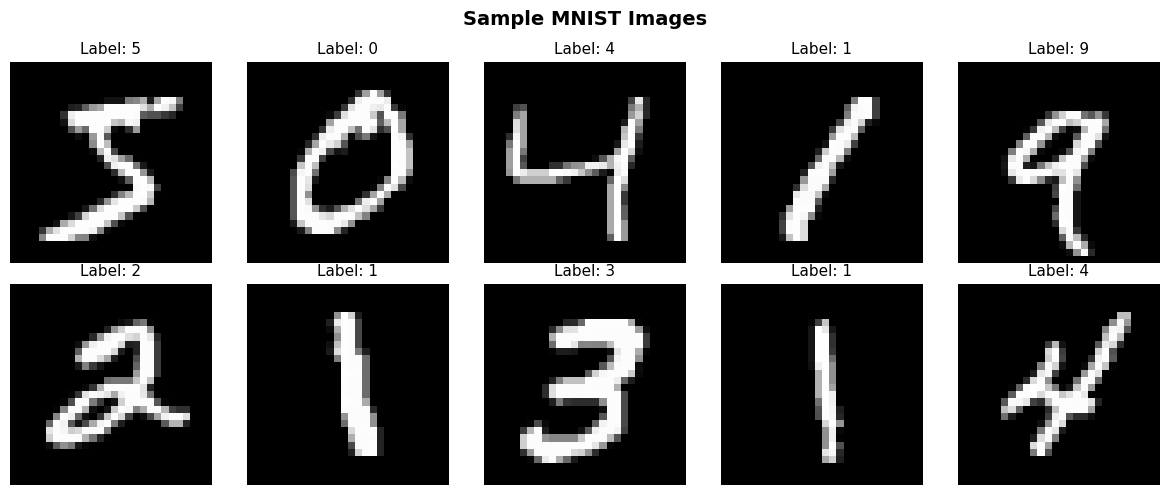

/tmp/ipykernel_683/1313826845.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, palette='viridis')


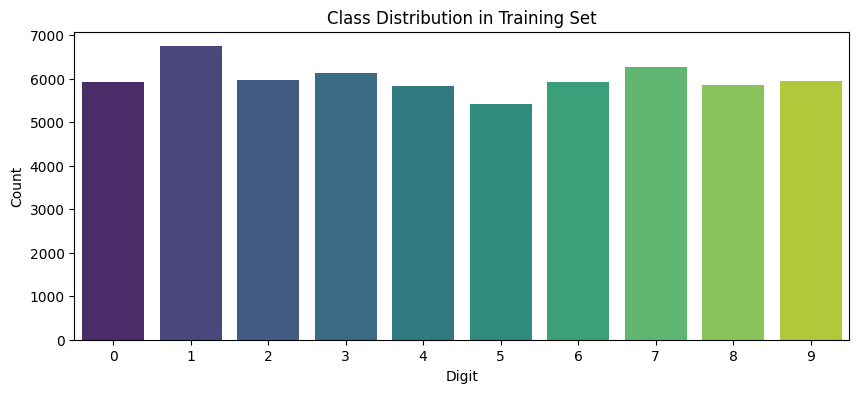

In [3]:
# Visualize 10 sample images with their labels
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample MNIST Images", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Class distribution — are classes balanced?
plt.figure(figsize=(10, 4))
sns.countplot(x=y_train, palette='viridis')
plt.title("Class Distribution in Training Set")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

In [4]:
def build_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([

        # ---- BLOCK 1: First pattern detector ----
        # 32 filters, each 3x3 pixels, looks for simple edges/curves
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape,
                      name='conv1'),
        # Keeps the strongest signal in each 2x2 region → halves spatial size
        layers.MaxPooling2D((2, 2), name='pool1'),

        # ---- BLOCK 2: Deeper pattern detector ----
        # 64 filters now — combines simple patterns into complex shapes
        layers.Conv2D(64, (3, 3), activation='relu', name='conv2'),
        layers.MaxPooling2D((2, 2), name='pool2'),

        # ---- BLOCK 3: Even deeper ----
        layers.Conv2D(64, (3, 3), activation='relu', name='conv3'),

        # ---- TRANSITION: 2D → 1D ----
        # Flatten 3D feature maps into a 1D vector for Dense layers
        layers.Flatten(name='flatten'),

        # ---- CLASSIFIER ----
        layers.Dense(128, activation='relu', name='dense1'),
        # Dropout randomly disables 50% of neurons during training
        # Forces the model to learn robust features, prevents memorization
        layers.Dropout(0.5, name='dropout'),

        # Output: 10 neurons (one per digit), softmax gives probabilities
        layers.Dense(num_classes, activation='softmax', name='output')
    ])
    return model

model = build_cnn()

# Compile — define optimizer, loss, and metric
model.compile(
    optimizer='adam',               # Adaptive learning rate optimizer
    loss='categorical_crossentropy',# Good for multi-class classification
    metrics=['accuracy']
)

# Print architecture summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# EarlyStopping: stops training if validation accuracy stops improving
# Saves time and prevents overfitting
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,           # Stop if no improvement for 3 epochs
    restore_best_weights=True,
    verbose=1
)

print("🚀 Starting training...\n")

history = model.fit(
    X_train, y_train_ohe,
    epochs=15,            # Max 15 passes through training data
    batch_size=128,       # Process 128 images at a time
    validation_split=0.1, # Use 10% of training data to monitor overfitting
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Starting training...

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8940 - loss: 0.3436 - val_accuracy: 0.9783 - val_loss: 0.0707
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9733 - loss: 0.0922 - val_accuracy: 0.9867 - val_loss: 0.0429
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9806 - loss: 0.0658 - val_accuracy: 0.9880 - val_loss: 0.0390
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9854 - loss: 0.0516 - val_accuracy: 0.9900 - val_loss: 0.0344
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9880 - loss: 0.0415 - val_accuracy: 0.9908 - val_loss: 0.0313
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9894 - loss: 0.0352 - val_accuracy: 0.9878 - val_loss: 0.0374
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9902 - loss: 0.0308 - val_accuracy: 0.9912 - val_loss: 0.0312
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9913 - loss:

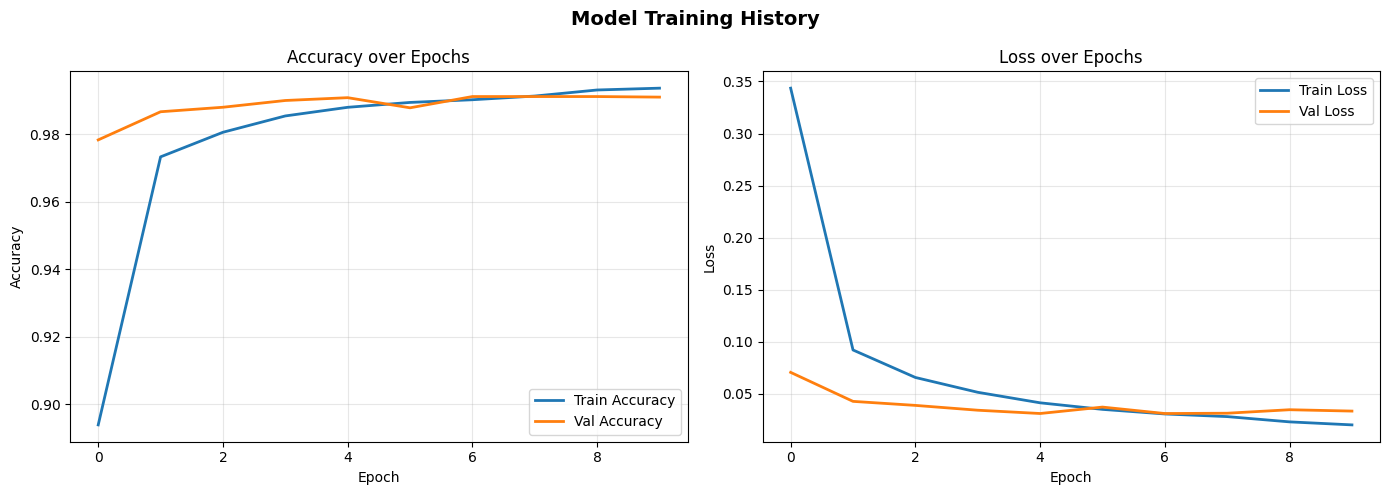

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training History", fontsize=14, fontweight='bold')

# Accuracy plot
ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# Final test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_ohe, verbose=0)
print(f"✅ Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"📉 Test Loss     : {test_loss:.4f}")

# Detailed per-class report
y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities → digit

print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=[str(i) for i in range(10)]))

✅ Test Accuracy : 99.15%
📉 Test Loss     : 0.0310

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



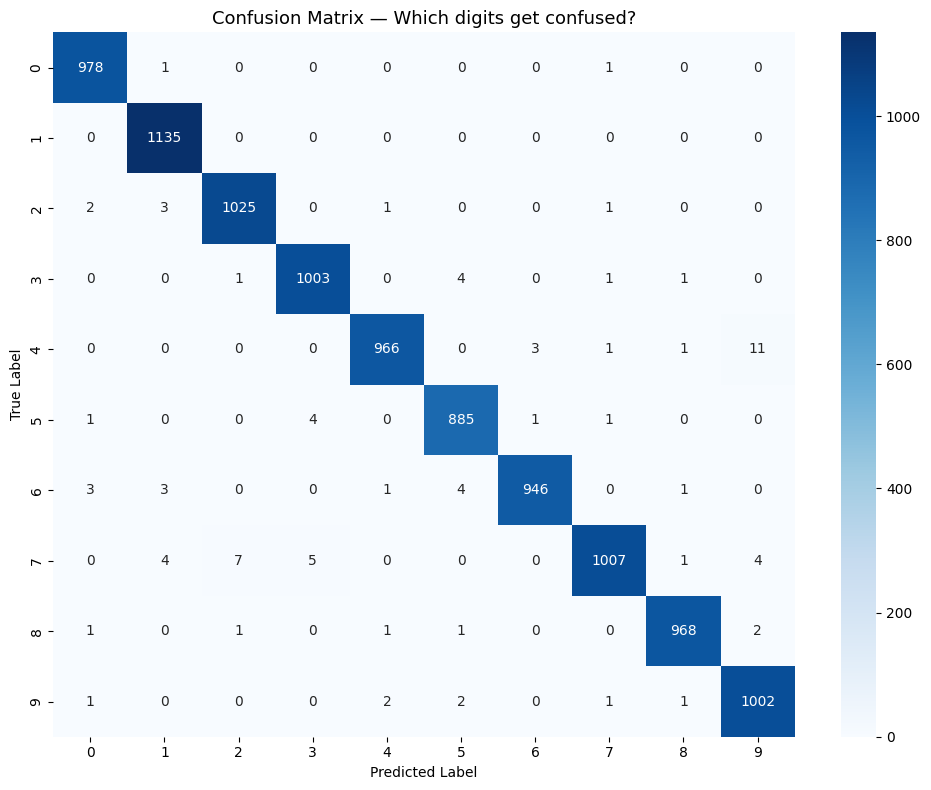


⚠️  Most misclassified digit: 7
   Total errors: 21


In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Which digits get confused?', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Which digit confuses the model most?
errors_per_class = cm.sum(axis=1) - np.diag(cm)
most_confused = np.argmax(errors_per_class)
print(f"\n⚠️  Most misclassified digit: {most_confused}")
print(f"   Total errors: {errors_per_class[most_confused]}")

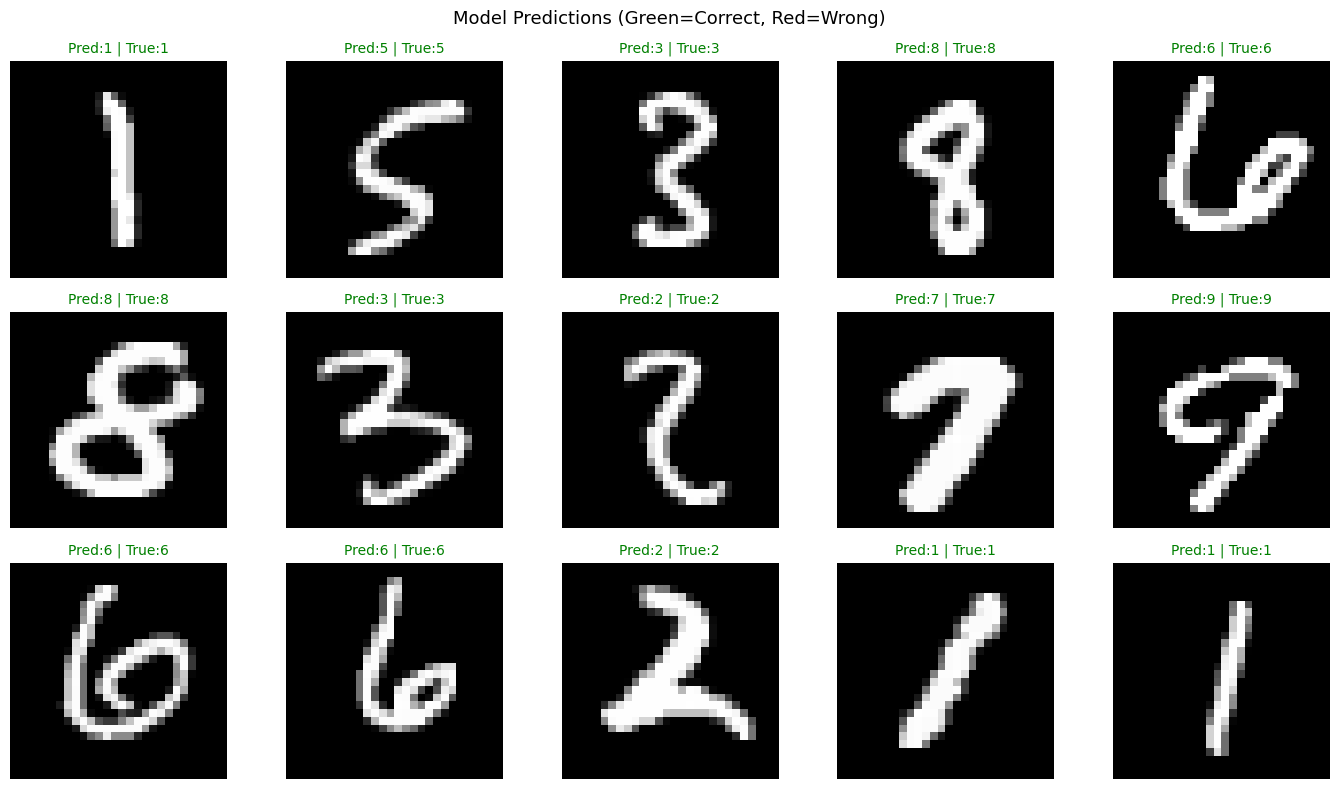

In [9]:
# Show 15 test images with predicted vs actual labels
fig, axes = plt.subplots(3, 5, figsize=(14, 8))
fig.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=13)

sample_idx = np.random.choice(len(X_test), 15, replace=False)

for i, (ax, idx) in enumerate(zip(axes.flat, sample_idx)):
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    pred  = y_pred[idx]
    actual = y_test[idx]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f"Pred:{pred} | True:{actual}", color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Save trained model for GitHub submission
model.save("handwritten_recognition_model.keras")
print("✅ Model saved as 'handwritten_recognition_model.keras'")

# Download it from Colab
from google.colab import files
files.download("handwritten_recognition_model.keras")

✅ Model saved as 'handwritten_recognition_model.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>